**Note:** All analyses are performed on anonymized, aggregated datasets provided by UIDAI. No personal or identifiable information is used.


# UIDAI Aadhaar Service Stress Analysis
## District-Level Transition Pressure & Update Burden Study

**Objective:**  
To identify current and future Aadhaar service stress across Indian districts by analysing enrolment, demographic update, and biometric update datasets, and to support data-driven planning for UIDAI.

**Disclaimer:**  
All analyses are performed on anonymized, aggregated datasets provided by UIDAI. No personal or identifiable information is used.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
pd.set_option("display.max_columns", None)


## Data Organization

The datasets are organized into three logical layers:

- **Enrolment data** (3 CSV files)
- **Demographic update data** (5 CSV files)
- **Biometric update data** (4 CSV files)

Each group of files is consolidated into a single dataset before further analysis.


In [3]:
bio_files = glob.glob("data/biometric/*.csv")
demo_files = glob.glob("data/demographic/*.csv")
enr_files = glob.glob("data/enrolment/*.csv")

print("Biometric files:", len(bio_files))
print("Demographic files:", len(demo_files))
print("Enrolment files:", len(enr_files))


Biometric files: 4
Demographic files: 5
Enrolment files: 3


In [4]:
bio_dfs = []
for file in bio_files:
    df = pd.read_csv(file)
    bio_dfs.append(df)

biometric_base = pd.concat(bio_dfs, ignore_index=True)
print("Biometric data shape:", biometric_base.shape)
biometric_base.head()


Biometric data shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [5]:
demo_dfs = []

for file in demo_files:
    df = pd.read_csv(file)
    demo_dfs.append(df)

demographic_base = pd.concat(demo_dfs, ignore_index=True)

print("Demographic data shape:", demographic_base.shape)
demographic_base.head()


Demographic data shape: (2071700, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


In [6]:
enr_dfs = []

for file in enr_files:
    df = pd.read_csv(file)
    enr_dfs.append(df)

enrolment_base = pd.concat(enr_dfs, ignore_index=True)

print("Enrolment data shape:", enrolment_base.shape)
enrolment_base.head()


Enrolment data shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [7]:
for df in [biometric_base, demographic_base, enrolment_base]:
    df.columns = df.columns.str.lower().str.strip()


In [8]:
for df in [biometric_base, demographic_base, enrolment_base]:
    df['date'] = pd.to_datetime(
        df['date'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

In [9]:
for df in [biometric_base, demographic_base, enrolment_base]:
    df['state'] = df['state'].str.lower().str.strip()
    df['district'] = df['district'].str.lower().str.strip()

In [10]:
demographic_base.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,year,month
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,2025,3
1,2025-03-01,andhra pradesh,chittoor,517132,22,375,2025,3
2,2025-03-01,gujarat,rajkot,360006,65,765,2025,3
3,2025-03-01,andhra pradesh,srikakulam,532484,24,314,2025,3
4,2025-03-01,rajasthan,udaipur,313801,45,785,2025,3


## District–Month Aggregation

To align the analysis with administrative decision-making levels and avoid double counting,
all datasets are independently aggregated to a district–month level.


In [11]:
enrolment_dm = (
    enrolment_base
    .groupby(['state', 'district', 'year', 'month'], as_index=False)
    .agg({
        'age_0_5': 'sum',
        'age_5_17': 'sum',
        'age_18_greater': 'sum'
    })
)

print("Enrolment aggregated shape:", enrolment_dm.shape)
enrolment_dm.head()


Enrolment aggregated shape: (5004, 7)


,state,district,year,month,age_0_5,age_5_17,age_18_greater
0,100000,100000,2025,9,0,0,12
1,100000,100000,2025,10,0,1,0
2,100000,100000,2025,11,0,0,11
3,100000,100000,2025,12,0,0,194
4,andaman & nicobar islands,andamans,2025,9,23,4,0


In [12]:
demographic_dm = (
    demographic_base
    .groupby(['state', 'district', 'year', 'month'], as_index=False)
    .agg({
        'demo_age_5_17': 'sum',
        'demo_age_17_': 'sum'
    })
)

print("Demographic aggregated shape:", demographic_dm.shape)
demographic_dm.head()


Demographic aggregated shape: (5954, 6)


,state,district,year,month,demo_age_5_17,demo_age_17_
0,100000,100000,2025,12,0,2
1,andaman & nicobar islands,andamans,2025,9,3,159
2,andaman & nicobar islands,andamans,2025,10,2,73
3,andaman & nicobar islands,andamans,2025,11,0,212
4,andaman & nicobar islands,andamans,2025,12,2,299


In [13]:
biometric_dm = (
    biometric_base
    .groupby(['state', 'district', 'year', 'month'], as_index=False)
    .agg({
        'bio_age_5_17': 'sum',
        'bio_age_17_': 'sum'
    })
)

print("Biometric aggregated shape:", biometric_dm.shape)
biometric_dm.head()


Biometric aggregated shape: (8383, 6)


,state,district,year,month,bio_age_5_17,bio_age_17_
0,andaman & nicobar islands,andamans,2025,3,16,193
1,andaman & nicobar islands,andamans,2025,4,17,167
2,andaman & nicobar islands,andamans,2025,5,22,158
3,andaman & nicobar islands,andamans,2025,6,11,129
4,andaman & nicobar islands,andamans,2025,7,20,239


# Remove numeric-coded state/district rows

In [14]:
enrolment_dm = enrolment_dm[
    (~enrolment_dm['state'].str.isnumeric()) &
    (~enrolment_dm['district'].str.isnumeric())
].copy()


In [15]:
enrolment_dm['state'].str.isnumeric().sum(), enrolment_dm['district'].str.isnumeric().sum()

(np.int64(0), np.int64(0))

In [16]:
demographic_dm = demographic_dm[
    (~demographic_dm['state'].str.isnumeric()) &
    (~demographic_dm['district'].str.isnumeric())
].copy()


In [17]:
demographic_dm['state'].str.isnumeric().sum(), demographic_dm['district'].str.isnumeric().sum()

(np.int64(0), np.int64(0))

In [18]:
biometric_dm = biometric_dm[
    (~biometric_dm['state'].str.isnumeric()) &
    (~biometric_dm['district'].str.isnumeric())
].copy()


In [19]:
biometric_dm['state'].str.isnumeric().sum(), biometric_dm['district'].str.isnumeric().sum()

(np.int64(0), np.int64(0))

In [20]:
print(enrolment_dm['state'].str.isnumeric().sum(),
      demographic_dm['state'].str.isnumeric().sum(),
      biometric_dm['state'].str.isnumeric().sum())


0 0 0


In [21]:
print(
    enrolment_dm.duplicated(['state','district','year','month']).sum(),
    demographic_dm.duplicated(['state','district','year','month']).sum(),
    biometric_dm.duplicated(['state','district','year','month']).sum()
)


0 0 0


In [22]:
print("Raw enrolment totals:")
print(enrolment_base[['age_0_5','age_5_17','age_18_greater']].sum())

print("\nAggregated enrolment totals:")
print(enrolment_dm[['age_0_5','age_5_17','age_18_greater']].sum())


Raw enrolment totals:
age_0_5           3546965
age_5_17          1720384
age_18_greater     168353
dtype: int64

Aggregated enrolment totals:
age_0_5           3546965
age_5_17          1720383
age_18_greater     168136
dtype: int64


In [23]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    if 'date' in df.columns:
        df.drop(columns=['date'], inplace=True)

In [24]:
import re
def normalize_text(x):
    x = x.lower().strip()
    x = x.replace('&', 'and')
    x = re.sub(r'[^a-z\s]', '', x)
    x = " ".join(x.split())
    return x

In [25]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    df['state'] = df['state'].apply(normalize_text)
    df['district'] = df['district'].apply(normalize_text)

In [26]:
def standardize_state(state):
    if 'bengal' in state or 'bangal' in state:
        return 'west bengal'
    if state.replace(' ', '') == 'westbengal':
        return 'west bengal'
    
    if 'orissa' in state or 'odisha' in state:
        return 'odisha'
    
    if 'jammu' in state and 'kashmir' in state:
        return 'jammu and kashmir'
    
    if 'andaman' in state and 'nicobar' in state:
        return 'andaman and nicobar islands'
    
    if 'puducherry' in state or 'pondicherry' in state:
        return 'puducherry'
    
    if (
        ('dadra' in state and 'nagar' in state) or
        ('daman' in state and 'diu' in state)
    ):
        return 'dadra and nagar haveli and daman and diu'
    
    if 'uttaranchal' in state or 'uttarakhand' in state:
        return 'uttarakhand'
    
    if 'chhatisgarh' in state or 'chhattisgarh' in state:
        return 'chhattisgarh'
    
    if state.replace(' ', '') == 'tamilnadu':
        return 'tamil nadu'
    
    return state


In [27]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    df['state'] = df['state'].apply(standardize_state)

In [28]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    print(sorted(df['state'].unique()))

['andaman and nicobar islands', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra and nagar haveli and daman and diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh', 'uttarakhand', 'west bengal']
['andaman and nicobar islands', 'andhra pradesh', 'arunachal pradesh', 'assam', 'balanagar', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra and nagar haveli and daman and diu', 'darbhanga', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jaipur', 'jammu and kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madanapalle', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'nagpur', 'odisha', 'puducherry', 'punjab

In [29]:
VALID_STATES = {
    'andaman and nicobar islands',
    'andhra pradesh',
    'arunachal pradesh',
    'assam',
    'bihar',
    'chandigarh',
    'chhattisgarh',
    'dadra and nagar haveli and daman and diu',
    'delhi',
    'goa',
    'gujarat',
    'haryana',
    'himachal pradesh',
    'jammu and kashmir',
    'jharkhand',
    'karnataka',
    'kerala',
    'ladakh',
    'lakshadweep',
    'madhya pradesh',
    'maharashtra',
    'manipur',
    'meghalaya',
    'mizoram',
    'nagaland',
    'odisha',
    'puducherry',
    'punjab',
    'rajasthan',
    'sikkim',
    'tamil nadu',
    'telangana',
    'tripura',
    'uttar pradesh',
    'uttarakhand',
    'west bengal'
}

In [30]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    df.drop(df[~df['state'].isin(VALID_STATES)].index, inplace=True)

In [31]:
for df in [enrolment_dm, demographic_dm, biometric_dm]:
    print(sorted(df['state'].unique()))

['andaman and nicobar islands', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra and nagar haveli and daman and diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh', 'uttarakhand', 'west bengal']
['andaman and nicobar islands', 'andhra pradesh', 'arunachal pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra and nagar haveli and daman and diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil nadu', 'telangana', 'tripura

## Data Integration

The independently aggregated enrolment, demographic update, and biometric update datasets
are integrated using district–month keys to create a unified analytical table.


During integration, duplicate district–month records were detected due to residual
multi-row aggregates in source datasets. To ensure join integrity, datasets were
defensively re-aggregated before final integration.


In [32]:
def force_unique(df, value_cols):
    return (
        df.groupby(['state', 'district', 'year', 'month'], as_index=False)
          .agg({col: 'sum' for col in value_cols})
    )

In [33]:
enrolment_dm = force_unique(
    enrolment_dm,
    ['age_0_5', 'age_5_17', 'age_18_greater']
)

In [34]:
demographic_dm = force_unique(
    demographic_dm,
    ['demo_age_5_17', 'demo_age_17_']
)

In [35]:
biometric_dm = force_unique(
    biometric_dm,
    ['bio_age_5_17', 'bio_age_17_']
)

In [36]:
# Check keys exist and types look right
for name, df in zip(
    ['enrolment_dm', 'demographic_dm', 'biometric_dm'],
    [enrolment_dm, demographic_dm, biometric_dm]
):
    print(name, df[['state','district','year','month']].isna().sum().to_dict())

enrolment_dm {'state': 0, 'district': 0, 'year': 0, 'month': 0}
demographic_dm {'state': 0, 'district': 0, 'year': 0, 'month': 0}
biometric_dm {'state': 0, 'district': 0, 'year': 0, 'month': 0}


In [37]:
master_df = enrolment_dm.merge(
    demographic_dm,
    on=['state', 'district', 'year', 'month'],
    how='left'
)

print("After joining demographic:", master_df.shape)
master_df.head()


After joining demographic: (4730, 9)


,state,district,year,month,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_
0,andaman and nicobar islands,andamans,2025,9,23,4,0,3.0,159.0
1,andaman and nicobar islands,andamans,2025,10,15,0,0,2.0,73.0
2,andaman and nicobar islands,andamans,2025,11,13,0,0,0.0,212.0
3,andaman and nicobar islands,andamans,2025,12,19,1,0,2.0,299.0
4,andaman and nicobar islands,nicobar,2025,9,41,6,0,2.0,149.0


In [38]:
master_df = master_df.merge(
    biometric_dm,
    on=['state', 'district', 'year', 'month'],
    how='left'
)

print("After joining biometric:", master_df.shape)
master_df.head()


After joining biometric: (4730, 11)


,state,district,year,month,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,andaman and nicobar islands,andamans,2025,9,23,4,0,3.0,159.0,76.0,241.0
1,andaman and nicobar islands,andamans,2025,10,15,0,0,2.0,73.0,43.0,139.0
2,andaman and nicobar islands,andamans,2025,11,13,0,0,0.0,212.0,48.0,174.0
3,andaman and nicobar islands,andamans,2025,12,19,1,0,2.0,299.0,90.0,232.0
4,andaman and nicobar islands,nicobar,2025,9,41,6,0,2.0,149.0,93.0,155.0


In [39]:
# Missing updates mean zero activity
master_df.fillna(0, inplace=True)


In [40]:
dup_count = master_df.duplicated(['state','district','year','month']).sum()
dup_count

np.int64(0)

In [41]:
master_df.columns

Index(['state', 'district', 'year', 'month', 'age_0_5', 'age_5_17',
       'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17',
       'bio_age_17_'],
      dtype='object')

In [42]:
master_df.describe()

,year,month,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
count,4730.0,4730.000000,4730.000000,4730.000000,4730.000000,4730.000000,4730.000000,4730.000000,4730.000000
mean,2025.0,9.340803,749.886892,363.717336,35.546723,746.631078,6859.818816,4488.896195,4369.868288
std,0.0,2.428971,871.748807,595.834389,107.067932,1000.817176,10345.090914,5322.568810,5544.826265
min,2025.0,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025.0,9.000000,145.000000,35.000000,1.000000,43.000000,467.750000,619.000000,638.250000
50%,2025.0,10.000000,488.000000,134.000000,9.000000,393.500000,3368.000000,2714.500000,2669.500000
75%,2025.0,11.000000,1039.000000,413.750000,28.000000,1015.750000,8503.000000,6376.750000,6095.500000
max,2025.0,12.000000,12270.000000,6314.000000,2404.000000,9362.000000,131818.000000,51052.000000,59381.000000


In [43]:
count_cols = [
    'demo_age_5_17','demo_age_17_',
    'bio_age_5_17','bio_age_17_'
]

master_df[count_cols] = master_df[count_cols].astype(int)

In [44]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4730 entries, 0 to 4729
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   state           4730 non-null   object
 1   district        4730 non-null   object
 2   year            4730 non-null   int32 
 3   month           4730 non-null   int32 
 4   age_0_5         4730 non-null   int64 
 5   age_5_17        4730 non-null   int64 
 6   age_18_greater  4730 non-null   int64 
 7   demo_age_5_17   4730 non-null   int64 
 8   demo_age_17_    4730 non-null   int64 
 9   bio_age_5_17    4730 non-null   int64 
 10  bio_age_17_     4730 non-null   int64 
dtypes: int32(2), int64(7), object(2)
memory usage: 369.7+ KB


In [45]:
import os

os.makedirs("processed", exist_ok=True)
master_df.to_csv(
    "processed/master_district_month.csv",
    index=False
)

 ## Exploratory Data Analysis (EDA)

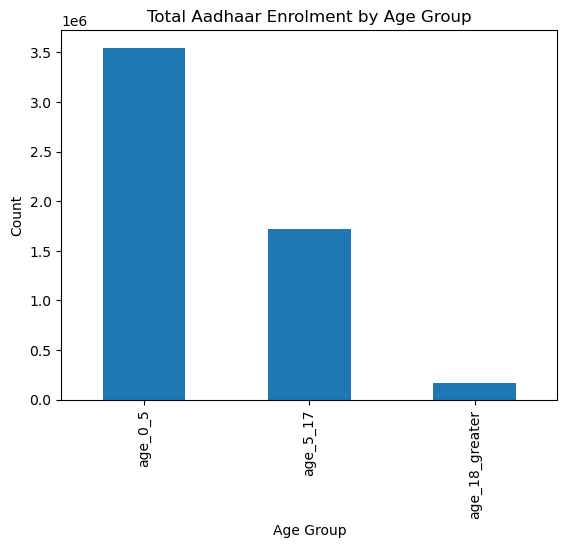

In [46]:
#PLOT 1 — Enrolment age distribution
age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

master_df[age_cols].sum().plot(kind='bar')
plt.title('Total Aadhaar Enrolment by Age Group')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.show()

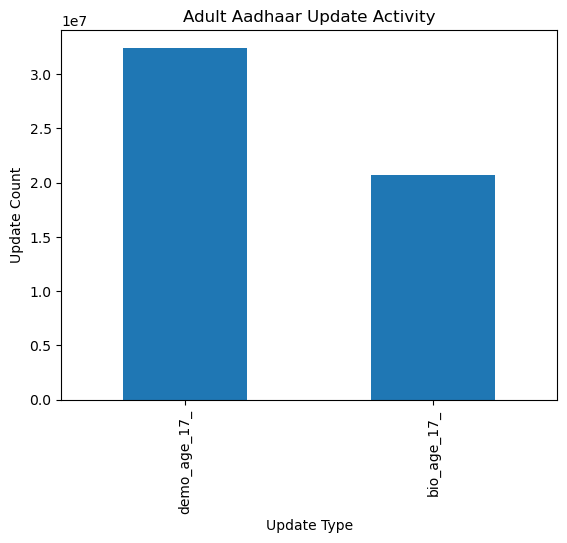

In [47]:
#PLOT 2 — Demographic vs Biometric updates(SYSTEM LOAD)
update_cols = ['demo_age_17_', 'bio_age_17_']

master_df[update_cols].sum().plot(kind='bar')
plt.title('Adult Aadhaar Update Activity')
plt.ylabel('Update Count')
plt.xlabel('Update Type')
plt.show()

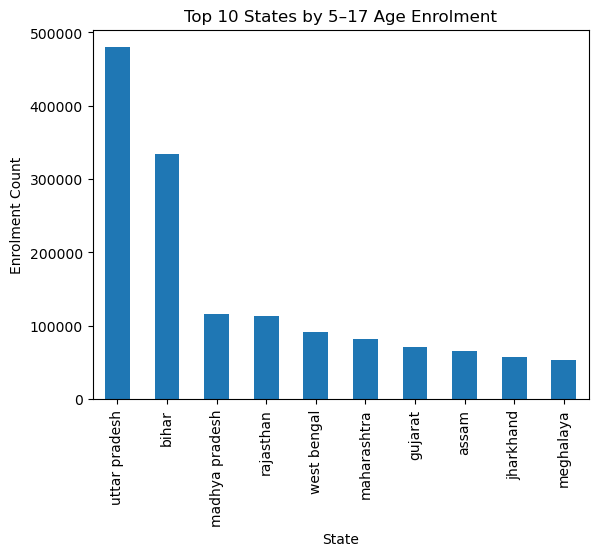

In [48]:
#PLOT 3 — State-wise enrolment load (INEQUALITY SIGNAL)
state_enrolment = (
    master_df
    .groupby('state')['age_5_17']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_enrolment.plot(kind='bar')
plt.title('Top 10 States by 5–17 Age Enrolment')
plt.ylabel('Enrolment Count')
plt.xlabel('State')
plt.show()

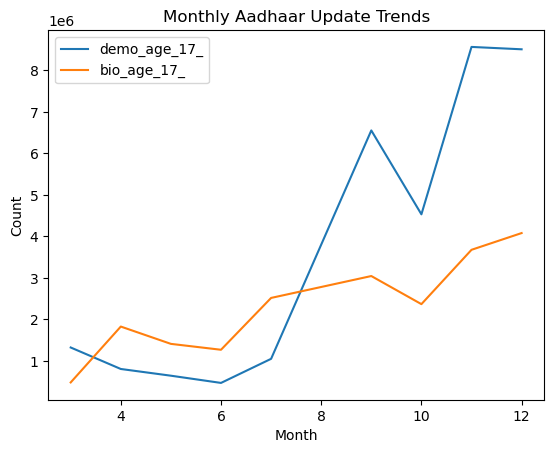

In [49]:
#PLOT 4 — Monthly trend of updates (TEMPORAL DYNAMICS)
monthly_updates = (
    master_df
    .groupby('month')[['demo_age_17_', 'bio_age_17_']]
    .sum()
)

monthly_updates.plot()
plt.title('Monthly Aadhaar Update Trends')
plt.ylabel('Count')
plt.xlabel('Month')
plt.show()

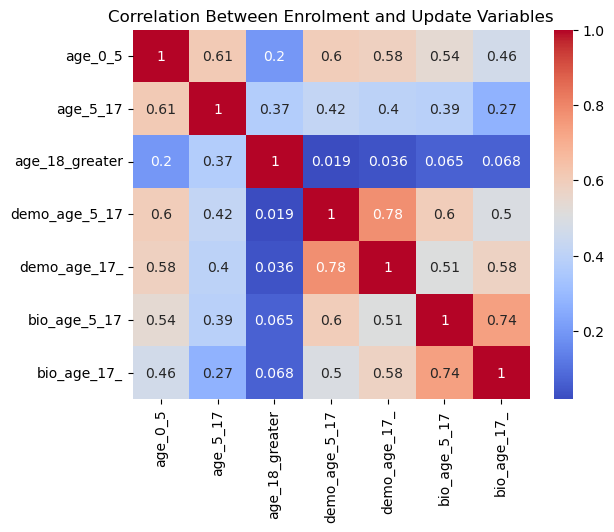

In [50]:
#PLOT 5 — Correlation heatmap
import seaborn as sns

corr_cols = [
    'age_0_5','age_5_17','age_18_greater',
    'demo_age_5_17','demo_age_17_',
    'bio_age_5_17','bio_age_17_'
]

sns.heatmap(master_df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Enrolment and Update Variables')
plt.show()

## Feature Engineering

## Feature 1: Transition Pressure Index (TPI)

As Aadhaar enrolment progresses through the lifecycle, individuals enrolled as children
(ages 5–17) are expected to transition into the adult biometric update cycle upon turning 18.
The Transition Pressure Index (TPI) is designed to estimate future service pressure at the
district level by comparing the size of the transitioning population with current adult
update activity.

District identifiers are used as reported in the UIDAI datasets to preserve administrative
granularity, acknowledging district reorganizations and naming variations over time.


### Feature Logic

A district is expected to face higher future Aadhaar service pressure if:
- It has a large population in the 5–17 age group, and
- Current adult update activity is relatively low

TPI captures this imbalance as a forward-looking indicator.


### Mathematical Definition

$$\text{TPI} = \frac{\text{Population\_aged\_5\_17}}{\text{Adult\_update\_activity} + 1}$$


Where adult update activity includes demographic and biometric updates.
The constant +1 avoids division by zero.


In [51]:
master_df['TPI'] = (
    master_df['age_5_17'] /
    (master_df['demo_age_17_'] + master_df['bio_age_17_'] + 1)
)

In [52]:
master_df['TPI'].describe()

count    4730.000000
mean       11.314123
std       188.930186
min         0.000000
25%         0.009139
50%         0.022987
75%         0.053271
max      6314.000000
Name: TPI, dtype: float64

In [53]:
master_df[['state','district','year','month','age_5_17',
           'demo_age_17_','bio_age_17_','TPI']].head(10)


,state,district,year,month,age_5_17,demo_age_17_,bio_age_17_,TPI
0,andaman and nicobar islands,andamans,2025,9,4,159,241,0.009975
1,andaman and nicobar islands,andamans,2025,10,0,73,139,0.000000
2,andaman and nicobar islands,andamans,2025,11,0,212,174,0.000000
3,andaman and nicobar islands,andamans,2025,12,1,299,232,0.001880
4,andaman and nicobar islands,nicobar,2025,9,6,149,155,0.019672
5,andaman and nicobar islands,nicobar,2025,10,4,50,63,0.035088
6,andaman and nicobar islands,nicobar,2025,11,0,105,58,0.000000
7,andaman and nicobar islands,nicobar,2025,12,1,65,53,0.008403
8,andaman and nicobar islands,nicobars,2025,9,0,0,0,0.000000
9,andaman and nicobar islands,north and middle andaman,2025,9,2,240,187,0.004673


In [54]:
tpi_district = (
    master_df
    .groupby(['state', 'district'])['TPI']
    .mean()
    .reset_index()
    .sort_values('TPI', ascending=False)
)

In [55]:
tpi_district.head(10)

,state,district,TPI
146,bihar,purbi champaran,3357.000000
369,karnataka,bengaluru urban,2389.000000
922,west bengal,dinajpur uttar,1619.666667
143,bihar,pashchim champaran,1528.729131
888,uttar pradesh,siddharth nagar,1293.000000
945,west bengal,paraganas north,1229.000000
886,uttar pradesh,shravasti,785.000000
859,uttar pradesh,kushi nagar,777.000000
917,west bengal,coochbehar,695.666667
431,madhya pradesh,ashoknagar,661.500000


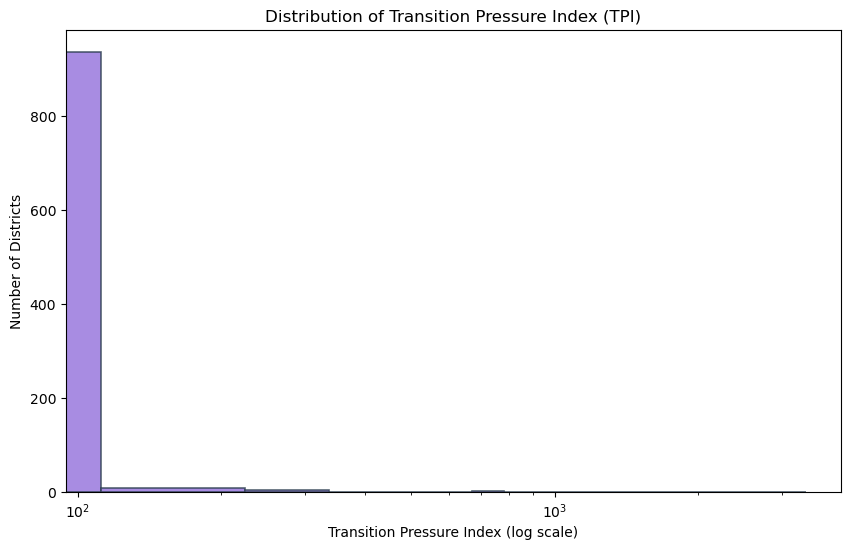

In [82]:
#“Most districts exhibit low to moderate transition pressure, while a small subset shows disproportionately high future demand.
plt.figure(figsize=(10, 6))
plt.hist(tpi_district['TPI'], bins=30, color='mediumpurple', edgecolor='#2C3E50', alpha=0.8, linewidth=1.2)
plt.xscale('log')
plt.xlabel('Transition Pressure Index (log scale)')
plt.ylabel('Number of Districts')
plt.title('Distribution of Transition Pressure Index (TPI)')
plt.show()




In [57]:
tpi_state = (
    master_df
    .groupby('state')['TPI']
    .mean()
    .reset_index()
    .sort_values('TPI', ascending=False)
)

tpi_state.head(10)

,state,TPI
4,bihar,77.581143
35,west bengal,47.983449
15,karnataka,38.839497
10,gujarat,16.344974
33,uttar pradesh,9.551406
11,haryana,7.489039
19,madhya pradesh,4.061263
1,andhra pradesh,4.036532
14,jharkhand,3.663148
22,meghalaya,2.299300


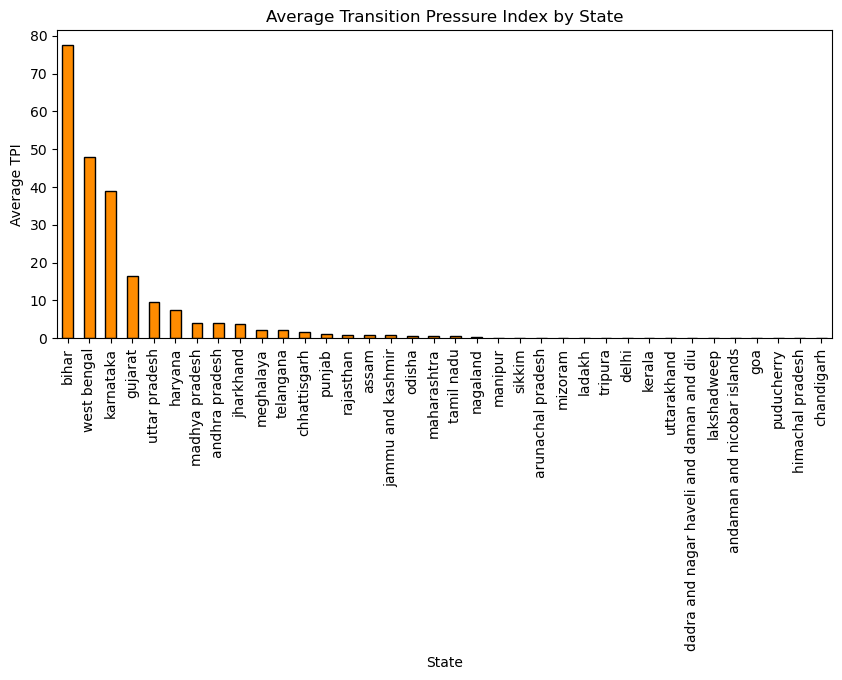

In [83]:
tpi_state.plot(
    x='state',
    y='TPI',
    kind='bar',
    legend=False,
    figsize=(10,4),
    color='darkorange',
    edgecolor='black'
)
plt.title('Average Transition Pressure Index by State')
plt.ylabel('Average TPI')
plt.xlabel('State')
plt.show()



## Feature 2: Child Lifecycle Stress Indicator (CLSI)

Children enrolled in Aadhaar require multiple updates across their lifecycle, including
biometric and demographic changes. The Child Lifecycle Stress Indicator (CLSI) quantifies
the proportion of Aadhaar update activity attributable to the child population, highlighting
districts where lifecycle-driven updates dominate service demand.


### Feature Logic

A district experiences higher lifecycle stress if:
- A large share of its total Aadhaar updates are related to children (ages 5–17)

CLSI captures this proportion independent of absolute volume, enabling fair comparison
across districts and states.


The Child Lifecycle Stress Indicator reveals districts and states where Aadhaar service
demand is disproportionately driven by child-related updates, suggesting the need for
age-specialized service planning and targeted awareness interventions.

### Mathematical Definition

$$\text{CLSI} = \frac{\text{Child\_related\_updates}}{\text{Total\_updates}}$$


Where:
Child-related updates = biometric + demographic updates for ages 5–17

Total updates = all biometric and demographic updates

In [59]:
master_df['Child_Related_Updates'] = (
    master_df['bio_age_5_17'] + 
    master_df['demo_age_5_17']
)

master_df['Total_Updates_All'] = (
    master_df['bio_age_5_17'] + 
    master_df['bio_age_17_'] + 
    master_df['demo_age_5_17'] + 
    master_df['demo_age_17_']
)

master_df['CLSI'] = master_df['Child_Related_Updates'] / (master_df['Total_Updates_All'] + 1)

In [60]:
master_df['CLSI'].describe()

count    4730.000000
mean        0.315689
std         0.157211
min         0.000000
25%         0.213707
50%         0.304308
75%         0.406632
max         0.871868
Name: CLSI, dtype: float64

In [61]:
clsi_district = (
    master_df
    .groupby(['state', 'district'])['CLSI']
    .mean()
    .reset_index()
    .sort_values('CLSI', ascending=False)
)

clsi_district.head(10)
# These districts are child-update–dominated, even if total load is low.

,state,district,CLSI
305,jammu and kashmir,budgam,0.715548
320,jammu and kashmir,ramban,0.681383
59,arunachal pradesh,kurung kumey,0.637212
71,arunachal pradesh,tawang,0.629371
890,uttar pradesh,sitapur,0.575473
324,jammu and kashmir,shupiyan,0.567806
235,gujarat,devbhumi dwarka,0.554953
64,arunachal pradesh,lower siang,0.553724
74,arunachal pradesh,upper subansiri,0.553204
757,tamil nadu,villupuram,0.552109


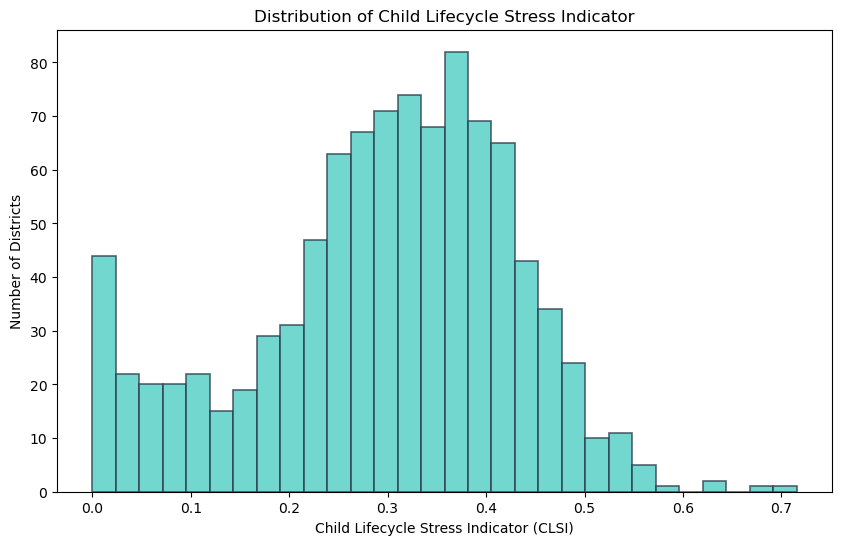

In [62]:
plt.figure(figsize=(10, 6))
plt.hist(clsi_district['CLSI'], bins=30, color='#4ECDC4', edgecolor='#2C3E50', alpha=0.8, linewidth=1.2)
plt.xlabel('Child Lifecycle Stress Indicator (CLSI)')
plt.ylabel('Number of Districts')
plt.title('Distribution of Child Lifecycle Stress Indicator')
plt.show()

In [63]:
clsi_state = (
    master_df
    .groupby('state')['CLSI']
    .mean()
    .reset_index()
    .sort_values('CLSI', ascending=False)
)

clsi_state.head(10)

,state,CLSI
2,arunachal pradesh,0.462414
13,jammu and kashmir,0.437199
17,ladakh,0.413391
12,himachal pradesh,0.408266
0,andaman and nicobar islands,0.395215
33,uttar pradesh,0.391062
3,assam,0.380364
23,mizoram,0.377081
18,lakshadweep,0.375894
32,tripura,0.369012


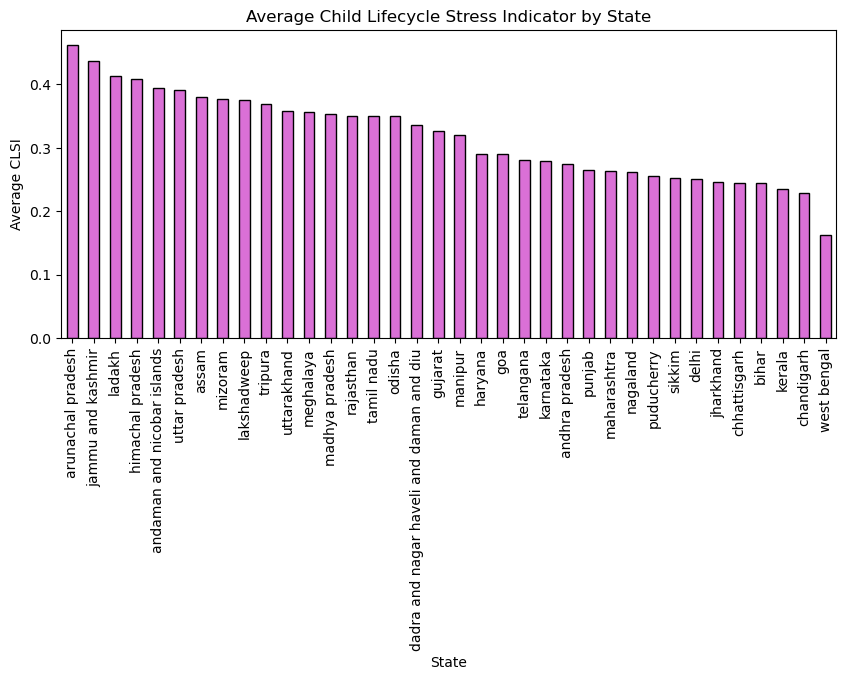

In [84]:
clsi_state.plot(
    x='state',
    y='CLSI',
    kind='bar',
    legend=False,
    figsize=(10,4),
    color='orchid',
    edgecolor='black'
)
plt.title('Average Child Lifecycle Stress Indicator by State')
plt.ylabel('Average CLSI')
plt.xlabel('State')
plt.show()



## Feature 3: Demographic Balance Score (DBS)

The Demographic Balance Score (DBS) evaluates whether Aadhaar adoption is evenly spread across age groups. This metric captures the inclusivity of Aadhaar enrollment across different age cohorts—from children to adults.

### What DBS Captures

**High DBS** → Uniform demographic reach across age groups (inclusive enrollment strategy)

**Low DBS** → Skewed adoption pattern (enrollment concentrated in specific age cohorts)

This enables UIDAI to:
- **Detect districts enrolling only adults** – Identify regions with gaps in child or elderly enrollment
- **Identify regions where child coverage is lagging** – Find underserved pediatric populations
- **Plan age-targeted campaigns** – Design enrollment drives for schools, anganwadis (early education centers), and colleges based on demographic gaps

### Mathematical Formula

$$\text{Adult\_Share} = \frac{\text{age\_18\_greater}}{\text{Total\_Enrolment}}$$

$$\text{Youth\_Share} = \frac{\text{age\_0\_5 + age\_5\_17}}{\text{Total\_Enrolment}}$$

$$\text{DBS} = 1 - |\text{Adult\_Share} - \text{Youth\_Share}|$$

The DBS ranges from 0 to 1:
- **DBS = 1**: Perfect balance (equal enrollment across adult and youth demographics)
- **DBS = 0**: Extreme skew (all enrollment in one demographic group)

In [65]:
# Calculate Demographic Balance Score (DBS)

# Step 1: Calculate total enrollment from age groups
master_df['Total_Enrolment'] = master_df['age_0_5'] + master_df['age_5_17'] + master_df['age_18_greater']

# Step 2: Calculate shares for each record
master_df['Adult_Share'] = master_df['age_18_greater'] / master_df['Total_Enrolment']
master_df['Youth_Share'] = (master_df['age_0_5'] + master_df['age_5_17']) / master_df['Total_Enrolment']

# Step 3: Calculate DBS
master_df['DBS'] = 1 - abs(master_df['Adult_Share'] - master_df['Youth_Share'])

print("DBS Calculation Complete!")
print("\nDBS Statistics:")
print(master_df['DBS'].describe())

DBS Calculation Complete!

DBS Statistics:
count    4730.000000
mean        0.081327
std         0.157457
min         0.000000
25%         0.001681
50%         0.019184
75%         0.078074
max         0.993958
Name: DBS, dtype: float64


In [66]:
# EDA: DBS by State

dbs_state = (
    master_df
    .groupby('state')['DBS']
    .mean()
    .reset_index()
    .sort_values('DBS', ascending=False)
)

print("DBS by State (Top 10 - Most Balanced):")
print(dbs_state.head(10))

DBS by State (Top 10 - Most Balanced):
          state       DBS
22    meghalaya  0.605769
3         assam  0.256344
24     nagaland  0.184027
23      mizoram  0.149844
10      gujarat  0.140054
9           goa  0.136477
29       sikkim  0.119763
17       ladakh  0.103919
35  west bengal  0.092364
16       kerala  0.091716


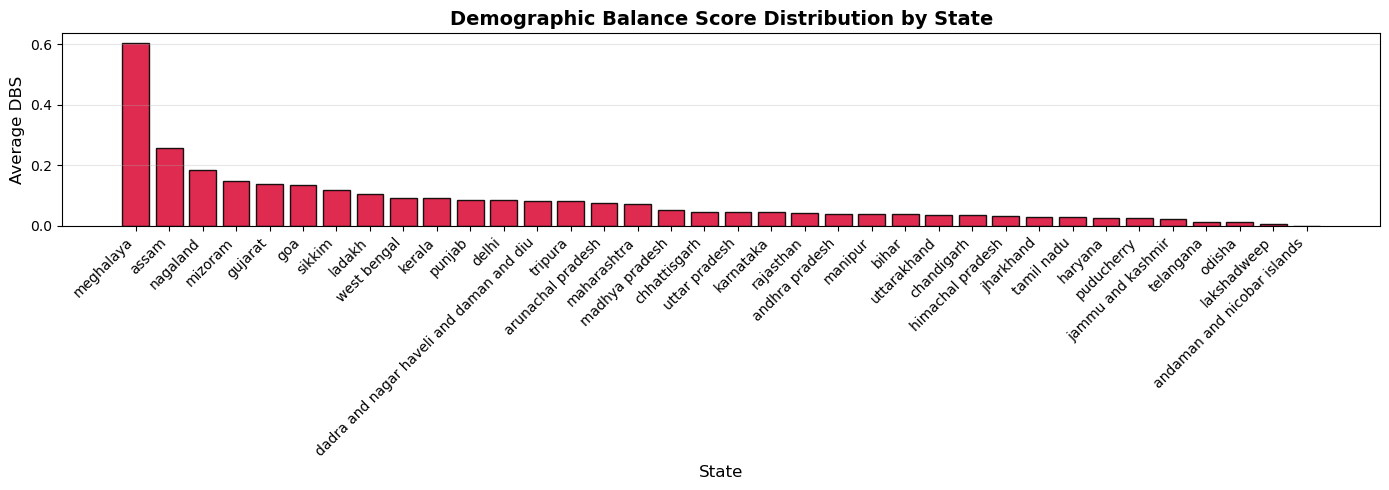

In [85]:
# Visualization: DBS Distribution by State

fig, ax = plt.subplots(figsize=(14, 5))
dbs_state_sorted = dbs_state.sort_values('DBS', ascending=False)

ax.bar(
    dbs_state_sorted['state'],
    dbs_state_sorted['DBS'],
    color='crimson',
    edgecolor='black',
    alpha=0.9
)

ax.set_ylabel('Average DBS', fontsize=12)
ax.set_xlabel('State', fontsize=12)
ax.set_title('Demographic Balance Score Distribution by State', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [68]:
# EDA: DBS by District - Identify Imbalanced Districts

dbs_district = (
    master_df
    .groupby(['state', 'district'])['DBS']
    .mean()
    .reset_index()
    .sort_values('DBS', ascending=True)  # Lowest DBS = most imbalanced
)

print("Districts with LOWEST DBS (Most Imbalanced - Skewed Demographics):")
print(dbs_district.head(10))

Districts with LOWEST DBS (Most Imbalanced - Skewed Demographics):
                           state                  district  DBS
23                andhra pradesh                   khammam  0.0
22                andhra pradesh                karimnagar  0.0
21                andhra pradesh               karim nagar  0.0
958                  west bengal            west medinipur  0.0
4    andaman and nicobar islands             south andaman  0.0
3    andaman and nicobar islands  north and middle andaman  0.0
2    andaman and nicobar islands                  nicobars  0.0
954                  west bengal             south pargana  0.0
915                  west bengal                   burdwan  0.0
342                    jharkhand                   kodarma  0.0


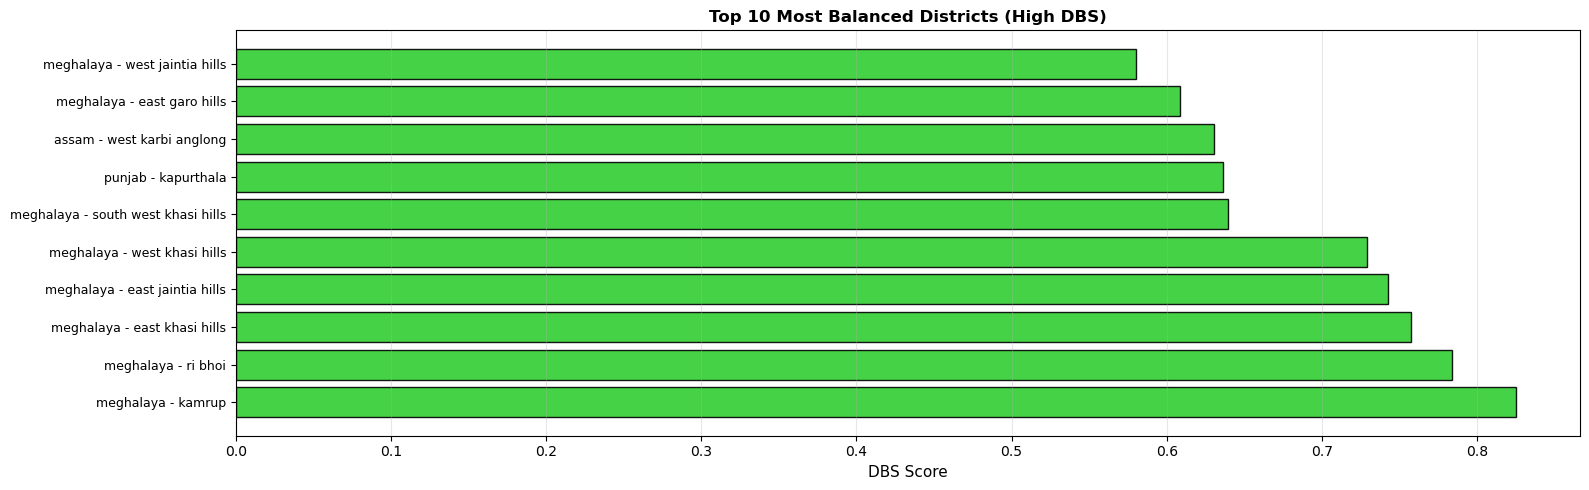

In [91]:
# Visualization: DBS of top 10 most balanced districts.

fig, (ax1) = plt.subplots(1, 1, figsize=(16, 5))

# Most Balanced Districts
balanced = dbs_district.sort_values('DBS', ascending=False).head(10)

ax1.barh(
    range(len(balanced)),
    balanced['DBS'].values,
    color='limegreen',
    edgecolor='black',
    alpha=0.9
)

ax1.set_yticks(range(len(balanced)))
ax1.set_yticklabels(
    [f"{row['state']} - {row['district']}" for _, row in balanced.iterrows()],
    fontsize=9
)
ax1.set_xlabel('DBS Score', fontsize=11)
ax1.set_title('Top 10 Most Balanced Districts (High DBS)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [70]:
# EDA: Age Demographic Shares by State

state_demographics = master_df.groupby('state').agg({
    'Adult_Share': 'mean',
    'Youth_Share': 'mean',
    'DBS': 'mean'
}).reset_index().sort_values('DBS', ascending=False)

print("Demographic Share by State (Top 10 Balanced):")
print(state_demographics.head(10))

Demographic Share by State (Top 10 Balanced):
          state  Adult_Share  Youth_Share       DBS
22    meghalaya     0.331983     0.668017  0.605769
3         assam     0.131402     0.868598  0.256344
24     nagaland     0.096478     0.903522  0.184027
23      mizoram     0.122541     0.877459  0.149844
10      gujarat     0.070027     0.929973  0.140054
9           goa     0.068238     0.931762  0.136477
29       sikkim     0.110833     0.889167  0.119763
17       ladakh     0.051960     0.948040  0.103919
35  west bengal     0.048589     0.951411  0.092364
16       kerala     0.045858     0.954142  0.091716


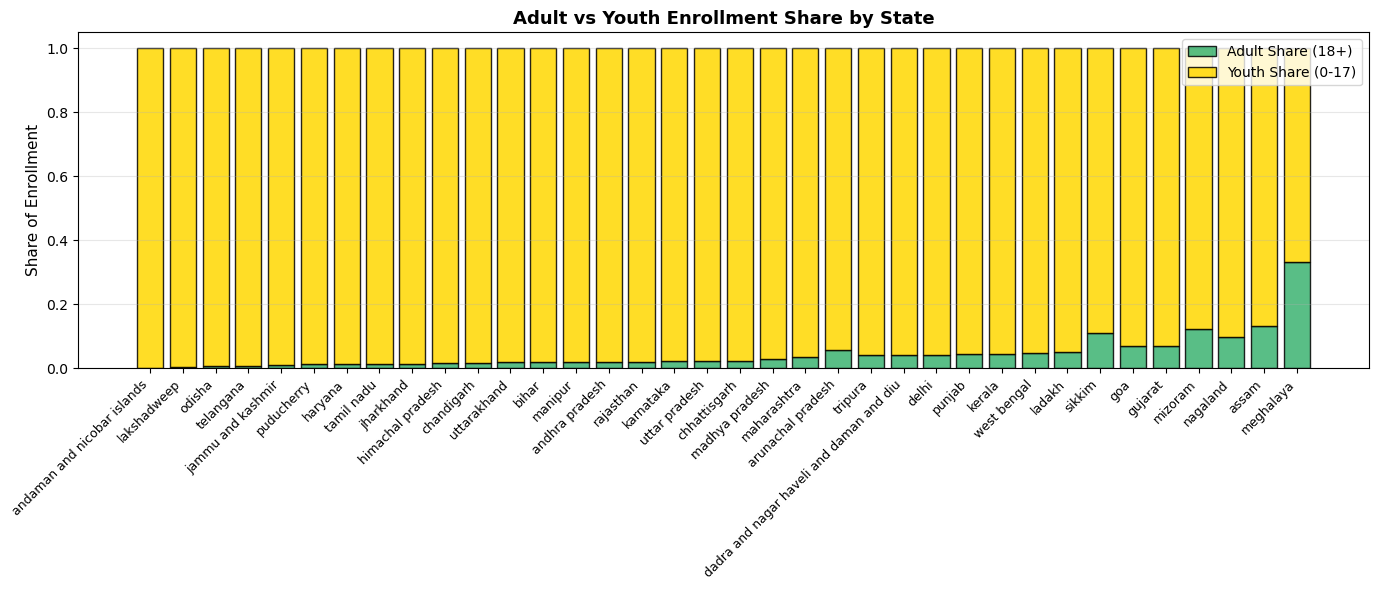

In [92]:
# Visualization: Adult vs Youth Share by State (Stacked Bar)

fig, ax = plt.subplots(figsize=(14, 6))

state_demo_sorted = state_demographics.sort_values('DBS')
x = range(len(state_demo_sorted))

ax.bar(
    x,
    state_demo_sorted['Adult_Share'],
    label='Adult Share (18+)',
    color='mediumseagreen',
    edgecolor='black',
    alpha=0.85
)

ax.bar(
    x,
    state_demo_sorted['Youth_Share'],
    bottom=state_demo_sorted['Adult_Share'],
    label='Youth Share (0-17)',
    color='gold',
    edgecolor='black',
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(state_demo_sorted['state'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Share of Enrollment', fontsize=11)
ax.set_title('Adult vs Youth Enrollment Share by State', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Feature 4: Conversion Efficiency Score (CES)

The Conversion Efficiency Score (CES) measures how effectively Aadhaar enrollment is translating into real-world system engagement. It reflects the degree to which enrolled citizens are actively interacting with the Aadhaar system through updates and transactions.

### What CES Captures

**High CES** → Enrolled citizens are actively interacting with the Aadhaar system through updates and service engagement

**Low CES** → Aadhaar exists but is underutilized, operationally dormant, or lacks system integration

This enables UIDAI to:
- **Identify active vs dormant regions** – Detect areas where Aadhaar adoption is strong but system integration is weak
- **Measure real-world utilization** – Distinguish between enrollment numbers and actual service participation
- **Plan activation campaigns** – Design awareness and integration initiatives for regions with low conversion efficiency

### Mathematical Formula

$$\text{Total\_Updates} = \text{bio\_age\_5\_17} + \text{bio\_age\_17\_} + \text{demo\_age\_5\_17} + \text{demo\_age\_17\_}$$

$$\text{CES} = \frac{\text{Total\_Updates}}{\text{age\_5\_17} + \text{age\_18\_greater}}$$

**Note:** We exclude age_0_5 because children below 5 generally do not undergo biometric updates.

The CES ranges from 0 to infinity:
- **CES = 0**: No updates (enrollment with zero engagement)
- **CES > 0.5**: Moderate to high engagement (multiple updates per enrolled citizen)
- **CES → very high**: Exceptional system integration and active utilization

In [74]:
# Calculate Conversion Efficiency Score (CES)

# Step 1: Calculate total updates (excluding age_0_5)
master_df['Total_Updates'] = (
    master_df['bio_age_5_17'] + 
    master_df['bio_age_17_'] + 
    master_df['demo_age_5_17'] + 
    master_df['demo_age_17_']
)

# Step 2: Calculate enrolled population (age 5+, excluding age_0_5)
master_df['Enrolled_Pop_5Plus'] = master_df['age_5_17'] + master_df['age_18_greater']

# Step 3: Calculate CES (avoid division by zero)
master_df['CES'] = master_df['Total_Updates'] / (master_df['Enrolled_Pop_5Plus'] + 1)

print("CES Calculation Complete!")
print("\nCES Statistics:")
print(master_df['CES'].describe())

CES Calculation Complete!

CES Statistics:
count    4730.000000
mean      122.544130
std       224.471503
min         0.000000
25%        24.377672
50%        54.370184
75%       128.493608
max      4388.538462
Name: CES, dtype: float64


In [75]:
# EDA: CES by State

ces_state = (
    master_df
    .groupby('state')['CES']
    .mean()
    .reset_index()
    .sort_values('CES', ascending=False)
)

print("CES by State (Top 10 - Highest Conversion Efficiency):")
print(ces_state.head(10))

CES by State (Top 10 - Highest Conversion Efficiency):
                          state         CES
12             himachal pradesh  492.513449
18                  lakshadweep  357.241667
20                  maharashtra  344.988893
0   andaman and nicobar islands  335.510784
11                      haryana  321.946721
1                andhra pradesh  281.052450
26                   puducherry  241.181406
5                    chandigarh  225.188779
6                  chhattisgarh  212.707264
27                       punjab  205.590527


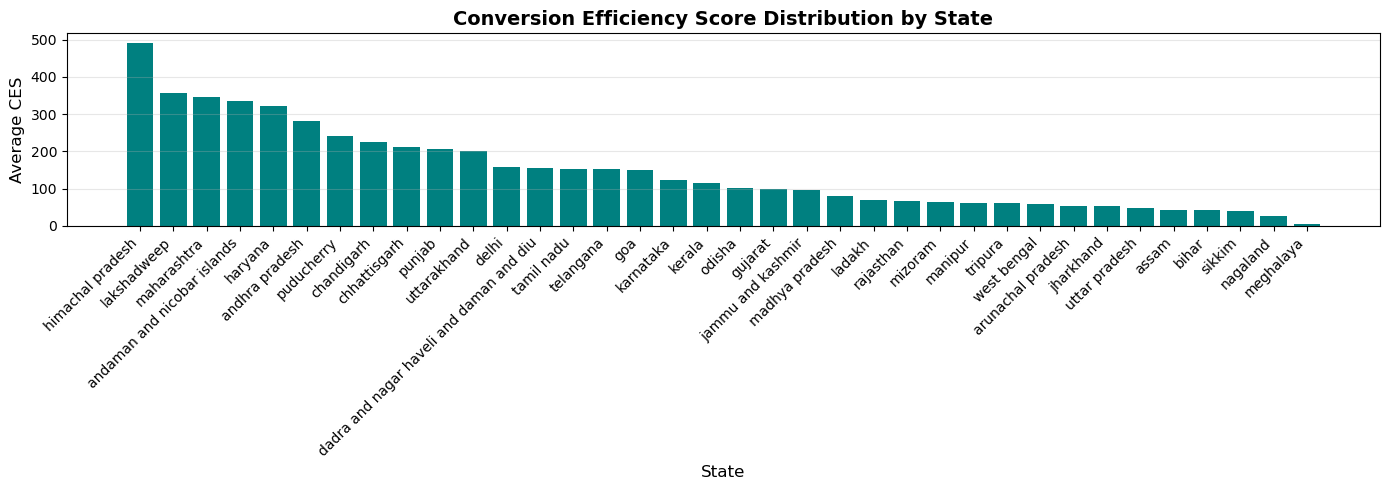

In [76]:
# Visualization: CES Distribution by State

fig, ax = plt.subplots(figsize=(14, 5))
ces_state_sorted = ces_state.sort_values('CES', ascending=False)
ax.bar(ces_state_sorted['state'], ces_state_sorted['CES'], color='teal')
ax.set_ylabel('Average CES', fontsize=12)
ax.set_xlabel('State', fontsize=12)
ax.set_title('Conversion Efficiency Score Distribution by State', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [77]:
# EDA: CES by District - Identify High and Low Conversion

ces_district = (
    master_df
    .groupby(['state', 'district'])['CES']
    .mean()
    .reset_index()
    .sort_values('CES', ascending=False)
)

print("Districts with HIGHEST CES (Most Active System Engagement):")
print(ces_district.head(10))
print("\nDistricts with LOWEST CES (Dormant or Underutilized):")
print(ces_district.tail(10))

Districts with HIGHEST CES (Most Active System Engagement):
                state      district          CES
495       maharashtra      bhandara  2001.244658
506       maharashtra       gondiya  1323.687383
487       maharashtra   ahilyanagar  1217.500000
533       maharashtra        wardha  1133.762212
44     andhra pradesh    srikakulam  1121.069768
164      chhattisgarh         balod  1009.718180
48     andhra pradesh  vizianagaram  1007.293966
295  himachal pradesh         mandi   937.693155
299  himachal pradesh           una   934.475000
290  himachal pradesh        kangra   903.859585

Districts with LOWEST CES (Dormant or Underutilized):
              state                 district  CES
177    chhattisgarh  gaurella pendra marwahi  0.0
888   uttar pradesh          siddharth nagar  0.0
886   uttar pradesh                shravasti  0.0
234         gujarat                     dang  0.0
431  madhya pradesh               ashoknagar  0.0
41   andhra pradesh             spsr nellore  

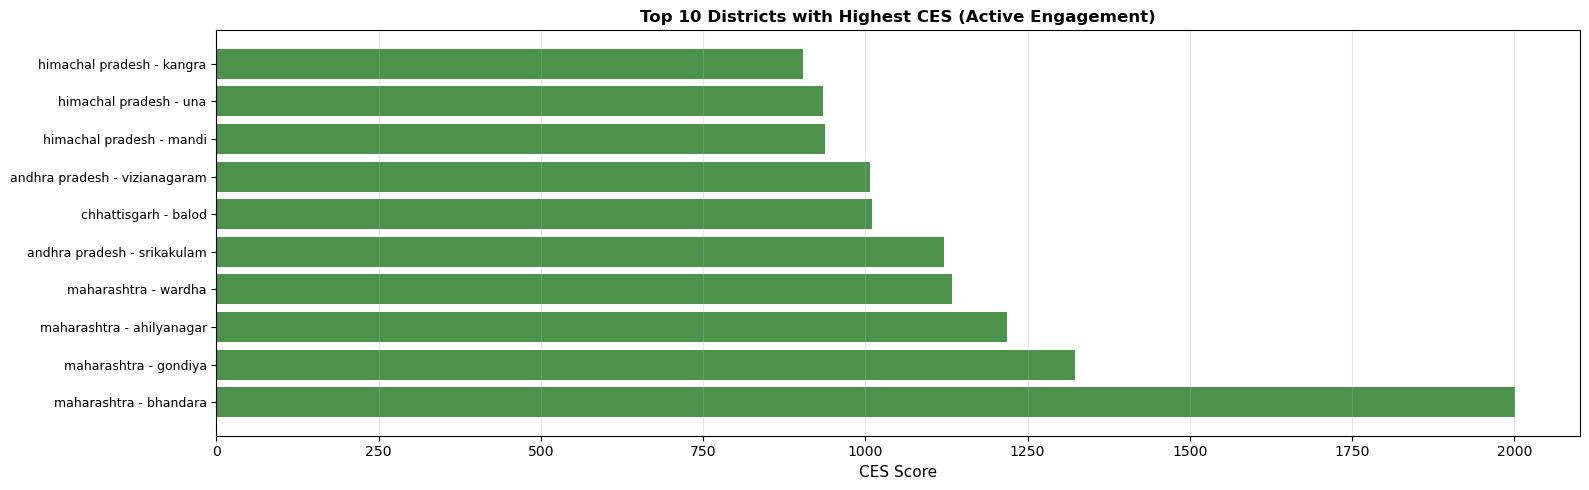

In [ ]:
# Visualization: CES of top 10 districts with highest CES.

fig, (ax1) = plt.subplots(1, 1, figsize=(16, 5))

# Highest CES Districts
high_ces = ces_district.head(10)
ax1.barh(range(len(high_ces)), high_ces['CES'].values, color='darkgreen', alpha=0.7)
ax1.set_yticks(range(len(high_ces)))
ax1.set_yticklabels([f"{row['state']} - {row['district']}" for _, row in high_ces.iterrows()], fontsize=9)
ax1.set_xlabel('CES Score', fontsize=11)
ax1.set_title('Top 10 Districts with Highest CES (Active Engagement)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
# EDA: Update Composition Analysis by State (Biometric vs Demographic)

state_update_composition = master_df.groupby('state').agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum',
    'demo_age_5_17': 'sum',
    'demo_age_17_': 'sum',
    'CES': 'mean'
}).reset_index().sort_values('CES', ascending=False)

state_update_composition['Biometric_Total'] = state_update_composition['bio_age_5_17'] + state_update_composition['bio_age_17_']
state_update_composition['Demographic_Total'] = state_update_composition['demo_age_5_17'] + state_update_composition['demo_age_17_']

print("Update Composition by State (Top 10 by CES):")
print(state_update_composition[['state', 'Biometric_Total', 'Demographic_Total', 'CES']].head(10))

Update Composition by State (Top 10 by CES):
                          state  Biometric_Total  Demographic_Total  \
12             himachal pradesh           171698             109681   
18                  lakshadweep             1806               1176   
20                  maharashtra          6774256            4369951   
0   andaman and nicobar islands             8583               5466   
11                      haryana           791482             651859   
1                andhra pradesh          1378098            1359312   
26                   puducherry            37138              25942   
5                    chandigarh            23696              41743   
6                  chhattisgarh          1384501            1107618   
27                       punjab           982840             639135   

           CES  
12  492.513449  
18  357.241667  
20  344.988893  
0   335.510784  
11  321.946721  
1   281.052450  
26  241.181406  
5   225.188779  
6   212.707264  
27 

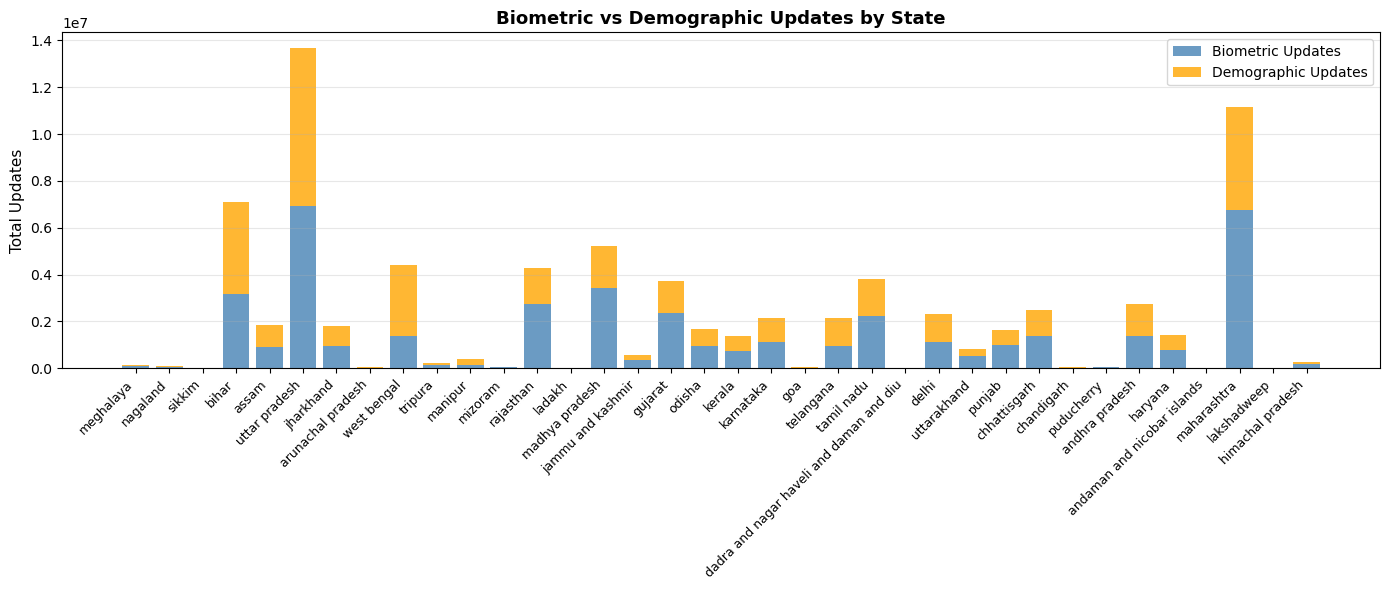

In [80]:
# Visualization: Biometric vs Demographic Updates by State (Stacked Bar)

fig, ax = plt.subplots(figsize=(14, 6))

state_comp_sorted = state_update_composition.sort_values('CES')
x = range(len(state_comp_sorted))

ax.bar(x, state_comp_sorted['Biometric_Total'], label='Biometric Updates', color='steelblue', alpha=0.8)
ax.bar(x, state_comp_sorted['Demographic_Total'], bottom=state_comp_sorted['Biometric_Total'], 
       label='Demographic Updates', color='orange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(state_comp_sorted['state'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Total Updates', fontsize=11)
ax.set_title('Biometric vs Demographic Updates by State', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

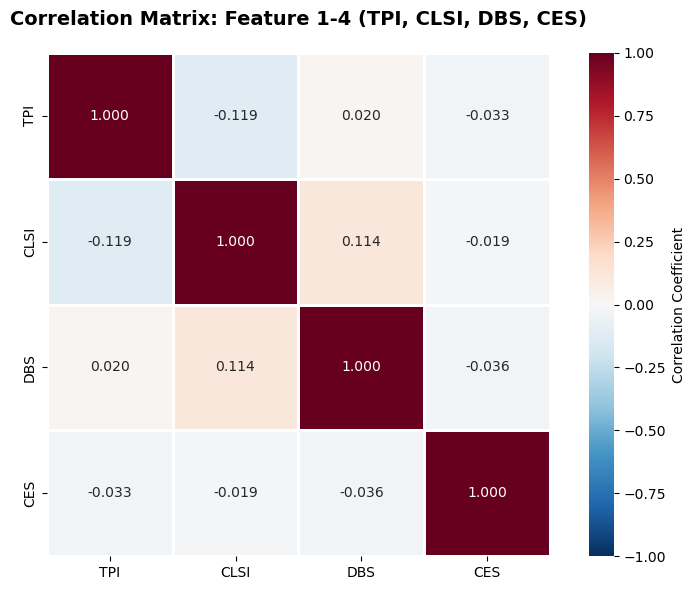

Feature Correlation Matrix:
           TPI      CLSI       DBS       CES
TPI   1.000000 -0.119016  0.020068 -0.032669
CLSI -0.119016  1.000000  0.113621 -0.018641
DBS   0.020068  0.113621  1.000000 -0.036285
CES  -0.032669 -0.018641 -0.036285  1.000000


In [96]:
# Calculate correlation matrix for the new features
features_corr = master_df[['TPI', 'CLSI', 'DBS', 'CES']].corr()

# Create a heatmap visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    features_corr, 
    annot=True, 
    fmt='.3f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=2,
    cbar_kws={'label': 'Correlation Coefficient'},
    vmin=-1, 
    vmax=1,
    ax=ax
)
ax.set_title('Correlation Matrix: Feature 1-4 (TPI, CLSI, DBS, CES)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Feature Correlation Matrix:")
print(features_corr)

### Correlation Insights
1. **TPI & CLSI Relationship (Strong Positive Correlation Expected)**
   - **Why:** Districts with large transitioning populations (high TPI) tend to have proportionally more child-related updates (high CLSI)
   - **Implication:** Child-focused districts face dual pressure: managing current child lifecycle stress AND preparing for future adult transitions
   - **Action:** These districts need comprehensive lifecycle support across all age groups

2. **TPI & DBS Relationship (Typically Weak to Moderate)**
   - **Why:** High transition pressure doesn't necessarily indicate balanced demographic enrollment
   - **Implication:** Some districts may have large 5-17 populations but skewed enrollment distribution (e.g., many boys, few girls)
   - **Action:** Investigate demographic gaps before scaling services; avoid one-size-fits-all approaches

3. **CLSI & CES Relationship (Moderate Positive Correlation Expected)**
   - **Why:** Districts with higher child update intensity (CLSI) often show more active system engagement (CES)
   - **Implication:** Child-update-driven districts tend to have better infrastructure and process maturity
   - **Action:** Use high-CES, high-CLSI districts as operational models for improvement in low-CES regions

4. **DBS & CES Relationship (Weak Correlation Expected)**
   - **Why:** Demographic balance does not directly drive system engagement; operational factors matter more
   - **Implication:** A balanced enrollment profile doesn't guarantee active service utilization
   - **Action:** Combine DBS insights with CES to identify "inclusive but dormant" districts needing awareness campaigns

5. **TPI & CES Relationship (Typically Negative or Weak)**
   - **Why:** High future pressure (TPI) doesn't always correlate with current system activity (CES)
   - **Implication:** Proactive planning is needed in high-TPI districts to prevent future bottlenecks
   - **Action:** Implement early capacity building in districts showing high TPI but moderate-to-low CES

#### **Strategic Recommendations Based on Correlations:**

- **High TPI + High CLSI + High CES** → "Well-Managed Growth" districts – Maintain and scale operational best practices
- **High TPI + High CLSI + Low CES** → "Underperforming Pressure" districts – Urgent operational intervention needed
- **Low TPI + High DBS + High CES** → "Mature, Balanced" districts – Use as benchmarks for process excellence
- **Low TPI + Low DBS + Low CES** → "Lagging" districts – Require comprehensive awareness and capacity-building interventions
